# Ejercicio 2 — Estimación del tamaño poblacional $N$ (problema de los tanques alemanes)

Una población de objetos está etiquetada consecutivamente del $1$ al $N$, con $N$ fijo pero desconocido.
Se extrae una **muestra aleatoria de tamaño $n$ sin reemplazo** y se registra la etiqueta observada más alta:

$$M = \max(X_1, X_2, \dots, X_n)$$

Caso analizado: $N = 200$ y $n = 15$.

En este cuaderno se resuelven los **pasos 1 a 3**:

1. Simular el experimento de muestreo al menos 1000 veces.
2. Registrar el valor máximo observado $M$ en cada repetición.
3. Representar el histograma de los resultados y calcular estadísticos descriptivos
   (media, varianza y desviación estándar).

## 0. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Parámetros del experimento
N = 200      # tamaño (desconocido en la práctica) de la población
n = 15       # tamaño de la muestra
REPS = 10_000  # número de repeticiones de la simulación (>= 1000)
SEED = 42    # semilla para reproducibilidad

rng = np.random.default_rng(SEED)

poblacion = np.arange(1, N + 1)  # etiquetas 1, 2, ..., N
print(f"Población: etiquetas {poblacion[0]} ... {poblacion[-1]}  (N = {N})")
print(f"Muestra sin reemplazo de tamaño n = {n}, repetida {REPS:,} veces")

Población: etiquetas 1 ... 200  (N = 200)
Muestra sin reemplazo de tamaño n = 15, repetida 10,000 veces


## 1. Simulación del experimento de muestreo

Cada repetición consiste en extraer $n = 15$ etiquetas **sin reemplazo** de $\{1, 2, \dots, 200\}$.
Se realizan 10,000 repeticiones (muy por encima del mínimo de 1000 solicitado).

In [2]:
def simular_muestra(rng, N=N, n=n):
    """Extrae una muestra aleatoria de tamaño n sin reemplazo de {1, ..., N}."""
    return rng.choice(np.arange(1, N + 1), size=n, replace=False)

# Ejemplo de una sola repetición
ejemplo = simular_muestra(rng)
print("Muestra de ejemplo:", np.sort(ejemplo))
print("Máximo observado M =", ejemplo.max())

Muestra de ejemplo: [ 17  19  40  83 104 124 135 144 145 146 152 164 190 192 193]
Máximo observado M = 193


In [3]:
# Simulación completa: cada fila de `muestras` es una repetición del experimento
rng = np.random.default_rng(SEED)  # se reinicia la semilla para reproducibilidad

muestras = np.array([simular_muestra(rng) for _ in range(REPS)])

print("Forma del arreglo de muestras:", muestras.shape, "(repeticiones x tamaño de muestra)")
print("\nPrimeras 5 repeticiones (ordenadas):")
print(np.sort(muestras[:5], axis=1))

Forma del arreglo de muestras: (10000, 15) (repeticiones x tamaño de muestra)

Primeras 5 repeticiones (ordenadas):
[[ 17  19  40  83 104 124 135 144 145 146 152 164 190 192 193]
 [ 13  18  33  43  54  71  83  85 106 124 140 151 161 166 170]
 [ 15  38  63  70  73  79  93 128 139 141 158 174 176 185 200]
 [ 28  40  47  56  59  75  83 126 134 144 153 157 161 166 174]
 [  7  16  22  27  47  84  91 111 114 126 127 128 151 166 200]]


## 2. Registro del valor máximo observado $M$

Para cada una de las repeticiones se guarda $M = \max(X_1, \dots, X_n)$.

In [4]:
M = muestras.max(axis=1)   # máximo de cada repetición

print("Número de valores registrados:", M.size)
print("Primeros 20 valores de M:", M[:20])
print(f"\nRango observado de M: [{M.min()}, {M.max()}]")

Número de valores registrados: 10000
Primeros 20 valores de M: [193 170 200 174 200 178 181 193 152 190 180 187 192 182 190 200 181 188
 199 187]

Rango observado de M: [100, 200]


In [5]:
# Tabla con los resultados de la simulación
resultados = pd.DataFrame({
    "repeticion": np.arange(1, REPS + 1),
    "M": M,
})
resultados.head(10)

,repeticion,M
0,1,193
1,2,170
2,3,200
3,4,174
4,5,200
5,6,178
6,7,181
7,8,193
8,9,152
9,10,190


## 3. Histograma y estadísticos descriptivos

In [6]:
media = M.mean()
varianza = M.var(ddof=1)        # varianza muestral (insesgada)
desv_est = M.std(ddof=1)        # desviación estándar muestral
mediana = np.median(M)
moda = np.bincount(M).argmax()

descriptivos = pd.Series({
    "Repeticiones": REPS,
    "Media": media,
    "Varianza": varianza,
    "Desviación estándar": desv_est,
    "Mediana": mediana,
    "Moda": moda,
    "Mínimo": M.min(),
    "Q1": np.percentile(M, 25),
    "Q3": np.percentile(M, 75),
    "Máximo": M.max(),
    "Rango intercuartílico": np.percentile(M, 75) - np.percentile(M, 25),
    "Coef. de variación": desv_est / media,
    "Sesgo (asimetría)": pd.Series(M).skew(),
    "Curtosis": pd.Series(M).kurt(),
}, name="Valor")

print("Estadísticos descriptivos de M = max(X_1, ..., X_15)\n")
descriptivos.to_frame().round(4)

Estadísticos descriptivos de M = max(X_1, ..., X_15)



,Valor
Repeticiones,10000.0000
Media,188.5600
Varianza,128.4980
Desviación estándar,11.3357
Mediana,192.0000
Moda,200.0000
Mínimo,100.0000
Q1,184.0000
Q3,197.0000
Máximo,200.0000


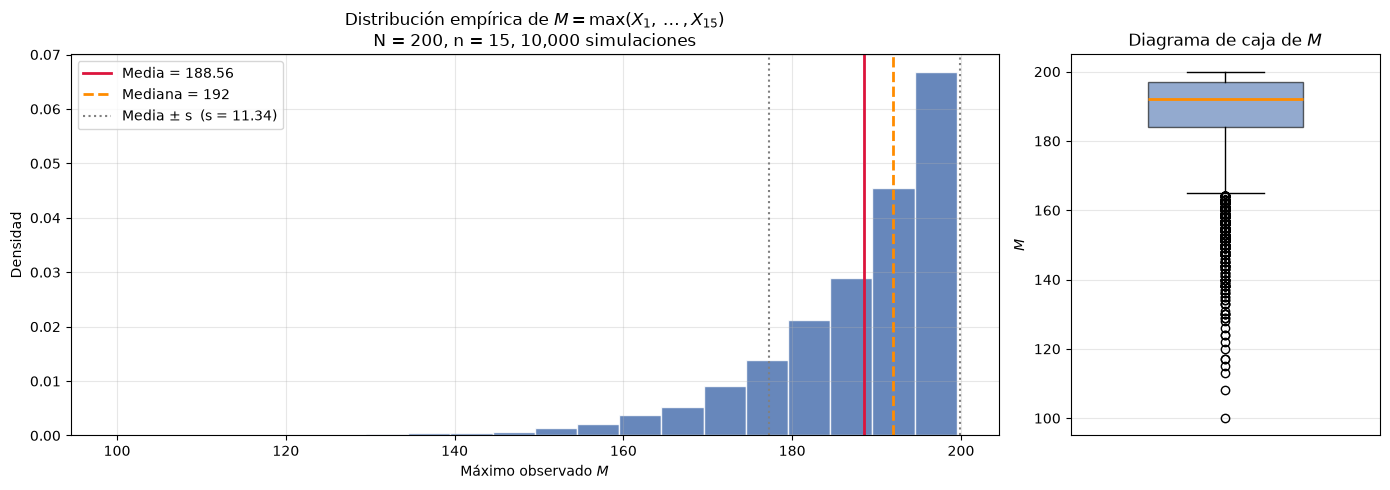

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 1]})

# --- Histograma ---
ax = axes[0]
bins = np.arange(M.min() - 0.5, M.max() + 1.5, 5)  # bins de ancho 5
ax.hist(M, bins=bins, density=True, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(media, color="crimson", lw=2, label=f"Media = {media:.2f}")
ax.axvline(mediana, color="darkorange", lw=2, ls="--", label=f"Mediana = {mediana:.0f}")
ax.axvline(media - desv_est, color="gray", lw=1.5, ls=":", label=f"Media ± s  (s = {desv_est:.2f})")
ax.axvline(media + desv_est, color="gray", lw=1.5, ls=":")
ax.set_title(f"Distribución empírica de $M=\\max(X_1,\\dots,X_{{{n}}})$\n"
             f"N = {N}, n = {n}, {REPS:,} simulaciones")
ax.set_xlabel("Máximo observado $M$")
ax.set_ylabel("Densidad")
ax.legend()

# --- Boxplot ---
ax = axes[1]
ax.boxplot(M, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="#4C72B0", alpha=0.6),
           medianprops=dict(color="darkorange", lw=2))
ax.set_title("Diagrama de caja de $M$")
ax.set_ylabel("$M$")
ax.set_xticks([])

plt.tight_layout()
plt.show()

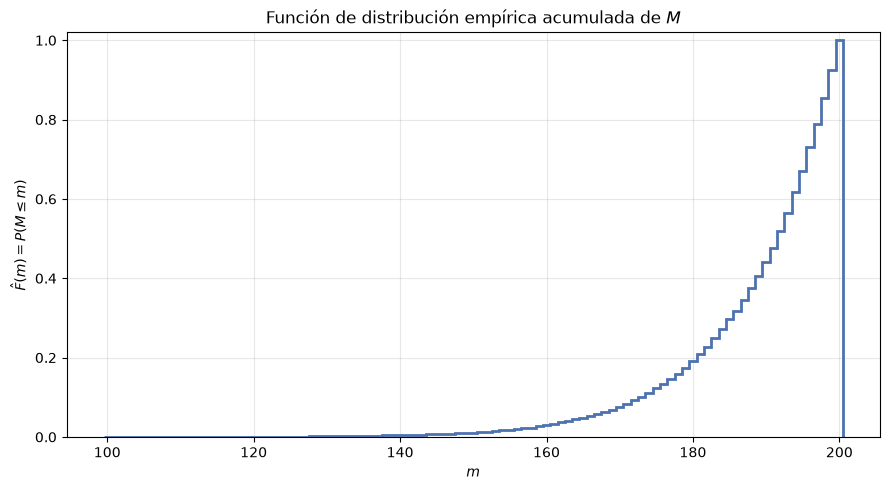

In [8]:
# Histograma acumulado (función de distribución empírica de M)
fig, ax = plt.subplots()
ax.hist(M, bins=np.arange(M.min() - 0.5, M.max() + 1.5, 1),
        density=True, cumulative=True, histtype="step", lw=2, color="#4C72B0")
ax.set_title("Función de distribución empírica acumulada de $M$")
ax.set_xlabel("$m$")
ax.set_ylabel(r"$\hat{F}(m) = P(M \leq m)$")
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

### Observaciones

- La distribución de $M$ está **fuertemente sesgada hacia la izquierda** (cola larga hacia
  valores pequeños): al tomar 15 etiquetas de 200, el máximo tiende a concentrarse cerca del
  extremo superior de la población.
- La media simulada es cercana a $\approx 188$, es decir, $M$ **subestima sistemáticamente** a
  $N = 200$; esto ya anticipa que el "Estimador 1: $\hat{N} = M$" tendrá sesgo negativo
  (esto se analiza formalmente en los pasos 4 y 5).
- La desviación estándar (~11) muestra que la variabilidad de $M$ es moderada respecto de la
  escala de la población.
- Como $M \le N$ siempre, ningún valor simulado supera 200, lo que produce el "corte" abrupto
  del histograma en el extremo derecho.